In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import scipy as sp


from unityvr.preproc import logproc
from unityvr.viz import viz

In [2]:
dirName = '/Volumes/otopaliklab/Aisha/Data/Test behavior/Fly04/'
fileName = "Log_2025-09-08_17-45-54_Fly04G.json"

dat = logproc.openUnityLog(dirName, fileName)

for i in range(5):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "headerNotes": "darkspot-20degspot-fh- 125degpersec-120fps- anglerange90deg-- panWidth_px-1504-panHeight_px-606 RED OFF                                           ",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.04500000178813934,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "meshGameObjectPath": "Fly/FlyCamera4/FlyCamera4Screen",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "worldPosition": {
        "x": -1.2334438562393188,
        "y": 0.0099999997

In [3]:
posDf, ftDf, tsDf = logproc.timeseriesDfFromLog(dat)

correcting for Unity angle convention.


### Plot time difference from frame time

Text(0, 0.5, 'Time difference [s]')

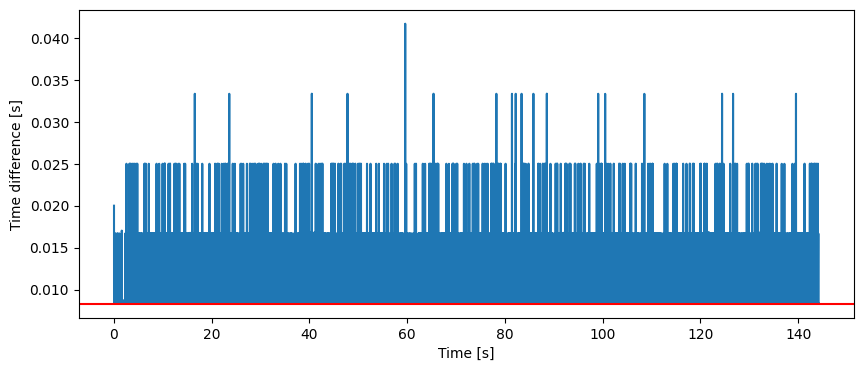

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(posDf['time'].iloc[1:], np.diff(posDf['time']))
plt.axhline(1/120, color = 'r')
plt.xlabel('Time [s]')
plt.ylabel('Time difference [s]')
# plt.xlim([2, 4])

In [6]:

expected_dt = 1 / 120  # Expected frame interval (in seconds)
time_diffs = np.diff(posDf['time'].values)

# Estimate dropped frames
dropped_frames = np.floor(time_diffs / expected_dt - 1).astype(int)
dropped_frames[dropped_frames < 0] = 0  # Sanity check

# Build a DataFrame for analysis or plotting
dropped_df = pd.DataFrame({
    'time': posDf['time'].iloc[1:].values,  # Each time is the timestamp of frame[i+1]
    'dropped_frames': dropped_frames
})

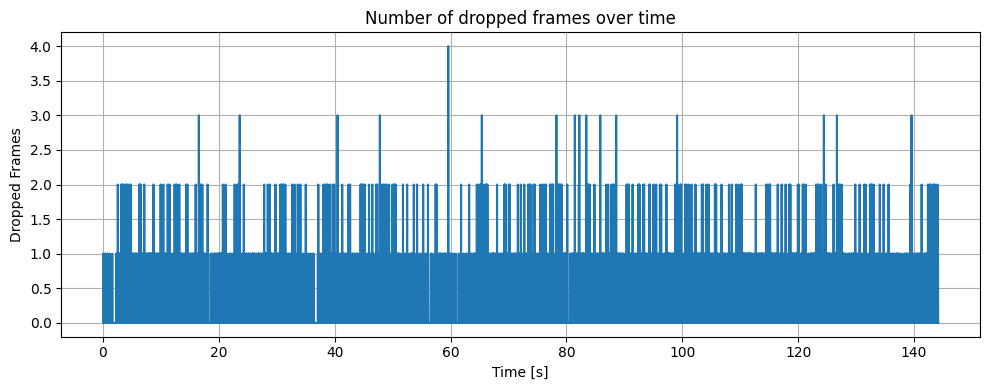

In [7]:

plt.figure(figsize=(10, 4))
plt.plot(dropped_df['time'], dropped_df['dropped_frames'], drawstyle='steps-post')
plt.xlabel('Time [s]')
plt.ylabel('Dropped Frames')
plt.title('Number of dropped frames over time')
plt.grid(True)
plt.tight_layout()
plt.show()

### Percent of dropped frames

In [8]:
# ensure clean ints
vals = pd.to_numeric(dropped_df['dropped_frames'], errors='coerce').fillna(0).astype(int)

bins = list(range(0, 13))  # 0..12 inclusive
pct = (vals.value_counts(normalize=True)
           .reindex(bins, fill_value=0)
           .mul(100))

for k in bins:
    print(f"Percent {k} dropped frame{'s' if k!=1 else ''}: {pct[k]:.2f}%")

# optional: anything beyond 12
pct_ge13 = 100.0 - pct.sum()
if pct_ge13 > 0:
    print(f"Percent ≥13 dropped frames: {pct_ge13:.2f}%")


Percent 0 dropped frames: 89.67%
Percent 1 dropped frame: 8.72%
Percent 2 dropped frames: 1.50%
Percent 3 dropped frames: 0.10%
Percent 4 dropped frames: 0.01%
Percent 5 dropped frames: 0.00%
Percent 6 dropped frames: 0.00%
Percent 7 dropped frames: 0.00%
Percent 8 dropped frames: 0.00%
Percent 9 dropped frames: 0.00%
Percent 10 dropped frames: 0.00%
Percent 11 dropped frames: 0.00%
Percent 12 dropped frames: 0.00%


### Stimulus angle plot

In [ ]:
# # Replace with the full path or relative path to your CSV
# df = pd.read_csv('/Users/hamida/Documents/GitHub/125deg-per-sec-45to45.csv')

# # Check the first few rows
# print(df.head())

# # Plot angle vs time
# plt.figure(figsize=(12, 4))
# plt.plot(df['time_s'], df['stimulus_angle_deg'], color='darkblue', label='Angular Position')
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
# plt.axhline(45, color='red', linestyle=':', linewidth=1, label='±45° limit')
# plt.axhline(45, color='red', linestyle=':', linewidth=1)
# plt.title('Spot Angular Position Over Time')
# plt.xlabel('Time (s)')
# plt.ylabel('Angular Position (°)')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [9]:
## All decimal points
from decimal import Decimal, getcontext, ROUND_HALF_UP
getcontext().prec = 50  # enough precision (>20 dp)

# Read as strings first so nothing is rounded
df = pd.read_csv('/Users/hamida/Documents/GitHub/125deg-per-sec-45to45.csv', dtype=str)

# Convert selected columns to Decimal (exact)
for col in ['time_s', 'stimulus_angle_deg']:
    df[col] = df[col].map(Decimal)

# Show full precision (Decimal prints all digits)
print(df.head().to_string(index=False))


              time_s  stimulus_angle_deg
                 0.0               -45.0
0.008372093023255813  -43.95348837209302
0.016744186046511626 -42.906976744186046
 0.02511627906976744 -41.860465116279066
 0.03348837209302325  -40.81395348837209


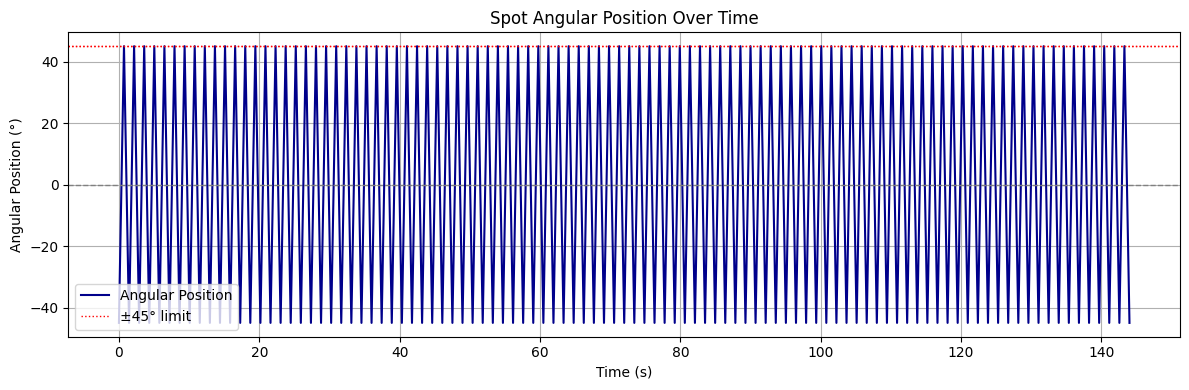

In [10]:
# Plot angle vs time
plt.figure(figsize=(12, 4))
plt.plot(df['time_s'], df['stimulus_angle_deg'], color='darkblue', label='Angular Position')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(45, color='red', linestyle=':', linewidth=1, label='±45° limit')
plt.axhline(45, color='red', linestyle=':', linewidth=1)
plt.title('Spot Angular Position Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (°)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Stimulus speed (deg/sec)

In [11]:

# Start from your df (time_s, stimulus_angle_deg), possibly read with Decimal
df_num = df.copy()

# 1) convert to float for math
df_num['time_s'] = pd.to_numeric(df_num['time_s'], errors='coerce')
df_num['stimulus_angle_deg'] = pd.to_numeric(df_num['stimulus_angle_deg'], errors='coerce')

# 2) drop NaNs and sort
df_num = df_num.dropna(subset=['time_s','stimulus_angle_deg']).sort_values('time_s')

# 3) collapse duplicate timestamps (avoid Δt=0)
df_num = df_num.groupby('time_s', as_index=False)['stimulus_angle_deg'].mean()

# 4) derivative (deg/s) — this is dθ/dt
t = df_num['time_s'].to_numpy()
theta = df_num['stimulus_angle_deg'].to_numpy()
omega = np.gradient(theta, t, edge_order=2)

# (Optional) if you want angular *speed* or d/dt |θ| instead:
# omega = np.abs(np.gradient(theta, t, edge_order=2))          # |dθ/dt|
omega = np.gradient(np.abs(theta), t, edge_order=2)          # d/dt |θ|


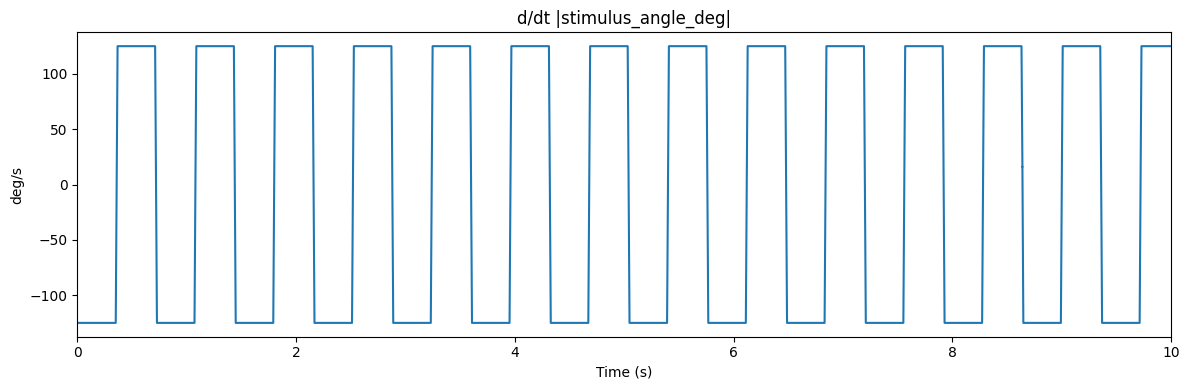

In [12]:
plt.figure(figsize=(12,4))
plt.plot(t, omega)
plt.xlabel('Time (s)')
plt.ylabel('deg/s')
plt.title('d/dt |stimulus_angle_deg|')
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

### Reconstruct oscillating position vs realtime position of the spot when dropping frames

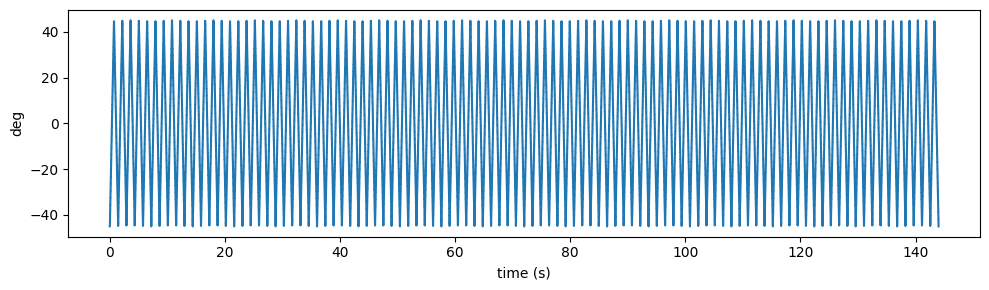

In [13]:
# Read as strings, convert to Decimal exactly
df = pd.read_csv('/Users/hamida/Documents/GitHub/125deg-per-sec-45to45.csv', dtype=str)
df['time_s'] = df['time_s'].map(Decimal)
df['stimulus_angle_deg'] = df['stimulus_angle_deg'].map(Decimal)

# Clean/sort
df = df.dropna(subset=['time_s','stimulus_angle_deg']).sort_values('time_s')

# Collapse duplicate timestamps with Decimal mean (compat-friendly)
df = (
    df.groupby('time_s', sort=True)['stimulus_angle_deg']
      .apply(lambda s: sum(s, Decimal(0)) / Decimal(len(s)))
      .reset_index(name='stimulus_angle_deg')
)

# Build 120 Hz Decimal grid
dt = Decimal(1) / Decimal(120)
T = df['time_s'].tolist()
Y = df['stimulus_angle_deg'].tolist()

t_grid = []
tg = T[0]
while tg <= T[-1] + Decimal('1e-30'):
    t_grid.append(tg)
    tg += dt

# Decimal linear interpolation
nominal_deg = []
i = 0; j = 1; n = len(T)
for tg in t_grid:
    while j < n and tg > T[j]:
        i += 1; j += 1
    if tg <= T[0]:
        nominal_deg.append(Y[0])
    elif tg >= T[-1]:
        nominal_deg.append(Y[-1])
    else:
        t0d, t1d = T[i], T[j]
        y0, y1 = Y[i], Y[j]
        if t1d == t0d:
            nominal_deg.append(y0)
        else:
            w = (tg - t0d) / (t1d - t0d)
            nominal_deg.append(y0 + w * (y1 - y0))

# Plot (convert to float ONLY for visualization)
t_grid_f = list(map(float, t_grid))
nominal_deg_f = list(map(float, nominal_deg))
plt.figure(figsize=(10,3))
plt.step(t_grid_f, nominal_deg_f, where='post')
plt.xlabel('time (s)'); plt.ylabel('deg'); plt.tight_layout(); plt.show()


In [46]:
# ---------- settings ----------
getcontext().prec = 50                          # keep 20+ dp safely
FRAME_RATE = 120
dtD = Decimal(1) / Decimal(FRAME_RATE)
x0, x1 = Decimal('80.0'), Decimal('85.0')        # set your zoom window (optional)

In [47]:
# ---------- 1) SOURCE DATA -> Decimal ----------
# If df already has Decimal columns, you can skip the mapping.
df_dec = df[['time_s','stimulus_angle_deg']].dropna().copy()
df_dec['time_s'] = df_dec['time_s'].map(lambda v: Decimal(str(v)))
df_dec['stimulus_angle_deg'] = df_dec['stimulus_angle_deg'].map(lambda v: Decimal(str(v)))
df_dec = df_dec.sort_values('time_s')

# Collapse any duplicate timestamps with a Decimal mean
df_dec = (
    df_dec.groupby('time_s', sort=True)['stimulus_angle_deg']
          .apply(lambda s: sum(s, Decimal(0)) / Decimal(len(s)))
          .reset_index(name='stimulus_angle_deg')
)

T = df_dec['time_s'].tolist()                    # list[Decimal]
Y = df_dec['stimulus_angle_deg'].tolist()        # list[Decimal]

# ---------- 2) Build exact 120 Hz Decimal grid ----------
t0D, t1D = T[0], T[-1]
t_grid = []
tg = t0D
while tg <= t1D + Decimal('1e-30'):
    t_grid.append(tg)
    tg += dtD

# ---------- 3) Interpolate nominal angle (linear, Decimal) ----------
nominal_dec = []
i = 0; j = 1; n = len(T)
for tg in t_grid:
    while j < n and tg > T[j]:
        i += 1; j += 1
    if tg <= T[0]:
        nominal_dec.append(Y[0])
    elif tg >= T[-1]:
        nominal_dec.append(Y[-1])
    else:
        tL, tR = T[i], T[j]
        yL, yR = Y[i], Y[j]
        if tR == tL:
            nominal_dec.append(yL)
        else:
            w = (tg - tL) / (tR - tL)
            nominal_dec.append(yL + w * (yR - yL))

In [48]:

# ---------- 4) Convert dropped_df to Decimal and build drop flags ----------
dd = dropped_df[['time','dropped_frames']].copy()
dd['time'] = dd['time'].map(lambda v: Decimal(str(v)))
dd['dropped_frames'] = dd['dropped_frames'].astype(int)
dd = dd.sort_values('time')

drop_flag = [False] * len(t_grid)

def idx_from_time_dec(tD: Decimal) -> int:
    # nearest grid index: round((t - t0)/dt)
    return int(((tD - t0D) / dtD).to_integral_value(rounding=ROUND_HALF_UP))

# Interpret each row as: N frames were dropped immediately BEFORE time=t_next
for t_next, N in zip(dd['time'].tolist(), dd['dropped_frames'].tolist()):
    if N <= 0:
        continue
    i_end = idx_from_time_dec(t_next)           # first good frame after the gap
    i_start = i_end - N                         # first dropped slot
    i_start = max(i_start, 0)
    i_end   = min(i_end, len(t_grid))
    if i_start < i_end:
        for k in range(i_start, i_end):
            drop_flag[k] = True

In [49]:
# ---------- 5) Reconstruct displayed = hold-previous on drops (Decimal) ----------
displayed_dec = list(nominal_dec)               # copy
for k in range(1, len(displayed_dec)):
    if drop_flag[k]:
        displayed_dec[k] = displayed_dec[k-1]   # hold previous

# Optional: error (Decimal)
error_dec = [displayed_dec[k] - nominal_dec[k] for k in range(len(t_grid))]


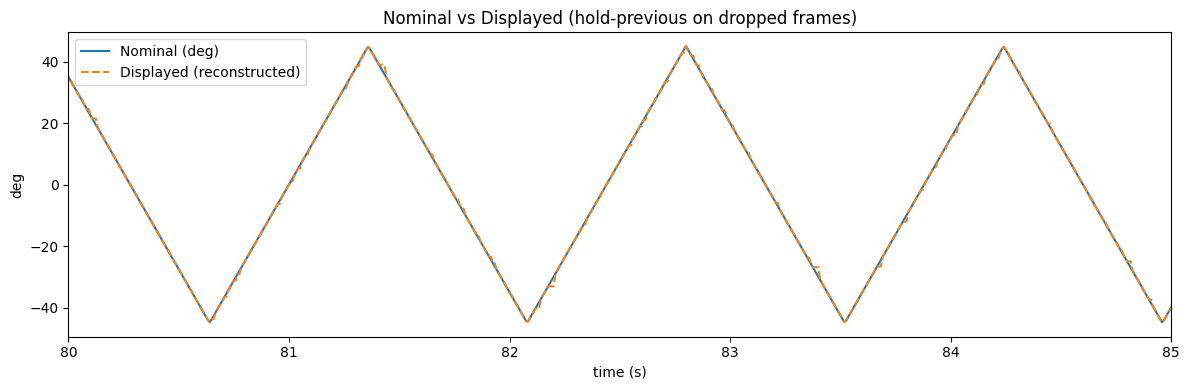

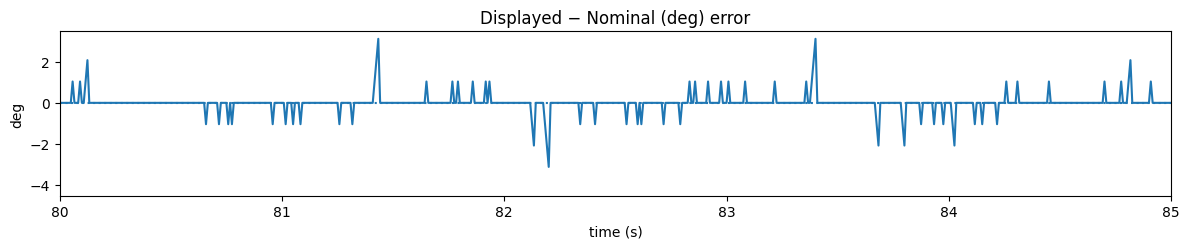

Example exact values:
t=0E-20 nominal=-45.00000000000000000000 displayed=-45.00000000000000000000
t=0.00833333333333333333 nominal=-43.95833333333332997396 displayed=-45.00000000000000000000
t=0.01666666666666666667 nominal=-42.91666666666666589236 displayed=-42.91666666666666589236


In [50]:

# ---------- 6) Plot (convert to float ONLY for visualization) ----------
t_grid_f      = list(map(float, t_grid))
nominal_f     = list(map(float, nominal_dec))
displayed_f   = list(map(float, displayed_dec))
error_f       = list(map(float, error_dec))
drop_flag_f   = np.array(drop_flag, dtype=int)

# Nominal vs displayed
plt.figure(figsize=(12,4))
plt.plot(t_grid_f, nominal_f, label='Nominal (deg)')
plt.plot(t_grid_f, displayed_f, '--', label='Displayed (reconstructed)')
plt.xlabel('time (s)'); plt.ylabel('deg'); plt.legend()
plt.xlim(float(x0), float(x1))                  # zoom (optional)
plt.title('Nominal vs Displayed (hold-previous on dropped frames)')
plt.tight_layout(); plt.show()

# Error (optional)
plt.figure(figsize=(12,2.6))
plt.plot(t_grid_f, error_f)
plt.axhline(0, linestyle=':')
plt.xlabel('time (s)'); plt.ylabel('deg')
plt.xlim(float(x0), float(x1))
plt.title('Displayed − Nominal (deg) error')
plt.tight_layout(); plt.show()

# # Drop raster (optional)
# plt.figure(figsize=(12,2.2))
# plt.step(t_grid_f, drop_flag_f, where='post')
# plt.yticks([0,1]); plt.ylim(-0.1, 1.1)
# plt.xlabel('time (s)'); plt.ylabel('drop')
# # plt.xlim(float(x0), float(x1))
# plt.title('Dropped frames (1 = dropped)')
# plt.tight_layout(); plt.show()

# ---------- 7) (Optional) exact prints with 20 dp ----------
q = Decimal('1e-20')
print("Example exact values:")
for k in range(3):
    print(f"t={t_grid[k].quantize(q)} nominal={nominal_dec[k].quantize(q)} displayed={displayed_dec[k].quantize(q)}")


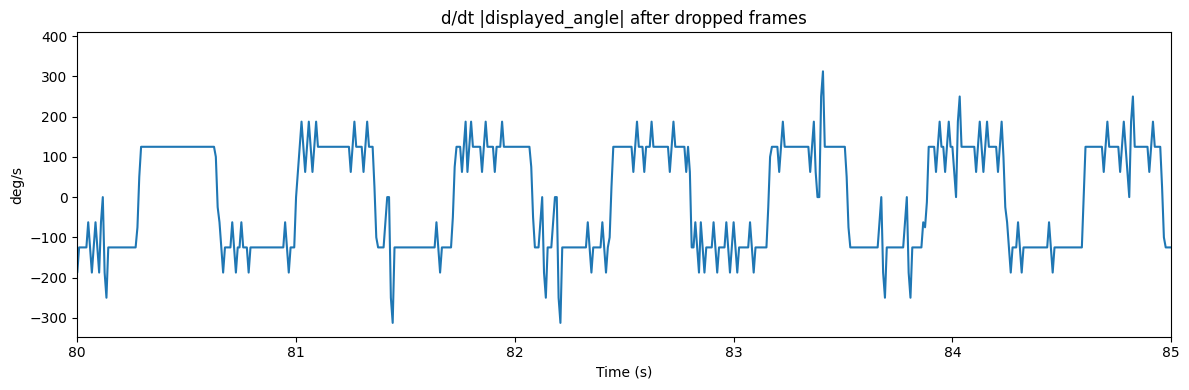

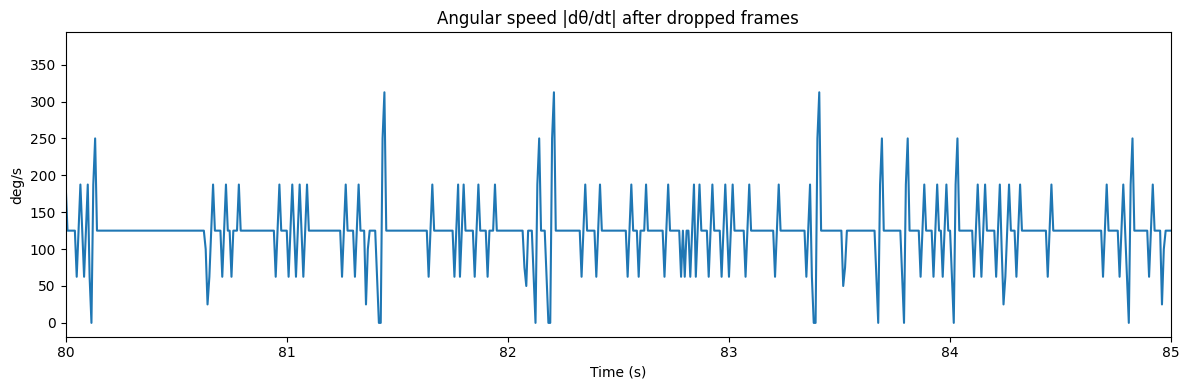

In [51]:
# Use reconstructed series on the 120 Hz grid:
# If you followed my Decimal pipeline:
t = np.asarray(t_grid_f, dtype=float)
theta = np.asarray(displayed_f, dtype=float)

# If instead you have numpy arrays already:
# t = t_grid.astype(float)
# theta = displayed_deg.astype(float)

dt = 1.0 / 120.0  # uniform grid spacing

# --- Choice A: derivative of absolute angle (signed; what you used before) ---
omega_abs_deriv = np.gradient(np.abs(theta), dt, edge_order=2)   # d/dt |θ|, deg/s

plt.figure(figsize=(12,4))
plt.plot(t, omega_abs_deriv)
plt.xlabel('Time (s)'); plt.ylabel('deg/s')
plt.title('d/dt |displayed_angle| after dropped frames')
plt.xlim(80.0, 85.0)
plt.tight_layout(); plt.show()

# --- Choice B (optional): angular speed (always ≥ 0) ---
omega_speed = np.abs(np.gradient(theta, dt, edge_order=2))      # |dθ/dt|, deg/s
plt.figure(figsize=(12,4))
plt.plot(t, omega_speed)
plt.xlabel('Time (s)'); plt.ylabel('deg/s')
plt.title('Angular speed |dθ/dt| after dropped frames')
plt.xlim(80.0, 85.0)
plt.tight_layout(); plt.show()


In [78]:
# Resample/interpolate onto a 120 Hz grid
FRAME_RATE = 120.0
dt = 1.0 / FRAME_RATE

# 1A) make a 120 Hz grid over your data window
t0 = float(df['time_s'].iloc[0])
t1 = float(df['time_s'].iloc[-1])
t_grid = np.arange(t0, t1 + 1e-12, dt)

# 1B) interpolate nominal angle onto that grid (no time warping)
nominal_deg = np.interp(t_grid, df['time_s'].values, df['stimulus_angle_deg'].values)

print("grid dt (should be ~0.008333s):", np.unique(np.round(np.diff(t_grid), 9))[:5])
print("grid length:", len(t_grid))
print("nominal_deg length:", len(nominal_deg))

# Quick look at a tiny window to see the interpolation
w = (t_grid >= t0) & (t_grid <= t0 + 160)  # first 0.2s
plt.figure(figsize=(10,3))
plt.plot(df['time_s'], df['stimulus_angle_deg'], '.', alpha=0.4, label='original samples')
plt.step(t_grid[w], nominal_deg[w], where='mid', label='nominal on 120Hz grid')
plt.xlabel('time (s)'); plt.ylabel('deg'); plt.legend(); plt.tight_layout(); plt.show()

TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [82]:
# Pick ONE row to inspect (change idx as you like)
idx = 0
t_next = float(dropped_df['time'].iloc[idx])
N = int(dropped_df['dropped_frames'].iloc[idx])
print(f"Example row: t_next={t_next:.6f}s, N={N} dropped right BEFORE t_next")

def idx_from_time(t):
    return int(np.round((t - t0) / dt))

i_end = idx_from_time(t_next)   # index of the first *good* frame after the gap
i_start = i_end - N             # index of the first dropped slot
print("grid indices covered by this drop run:", list(range(max(i_start,0), min(i_end, len(t_grid)))))

# Visualize just this little neighborhood
j0 = max(i_start - 5, 0)
j1 = min(i_end + 5, len(t_grid))
plt.figure(figsize=(10,3))
plt.plot(t_grid[j0:j1], nominal_deg[j0:j1], label='nominal on grid')
for i in range(max(i_start,0), min(i_end, len(t_grid))):
    plt.axvspan(t_grid[i]-0.5*dt, t_grid[i]+0.5*dt, alpha=0.2, label='marked dropped' if i==max(i_start,0) else None)
plt.xlabel('time (s)'); plt.ylabel('deg'); plt.legend(); plt.tight_layout(); plt.show()


Example row: t_next=0.020000s, N=1 dropped right BEFORE t_next


TypeError: unsupported operand type(s) for /: 'float' and 'decimal.Decimal'

In [83]:

drop_flag = np.zeros_like(t_grid, dtype=bool)

def mark_drops_for_row(t_next, N):
    i_end = idx_from_time(t_next)
    i_start = i_end - N
    i_start = max(i_start, 0)
    i_end   = min(i_end, len(t_grid))
    if i_start < i_end:
        drop_flag[i_start:i_end] = True

for t_next, N in zip(dropped_df['time'].values, dropped_df['dropped_frames'].values):
    if int(N) > 0:
        mark_drops_for_row(float(t_next), int(N))

print("Total dropped frame slots:", int(drop_flag.sum()))
print("Any drop runs longer than 1? ->", np.any(np.diff(np.where(drop_flag)[0]) == 1))

# Visualize the drop raster
plt.figure(figsize=(10,2.2))
plt.step(t_grid, drop_flag.astype(int), where='post')
plt.yticks([0,1]); plt.ylim(-0.1, 1.1)
plt.xlabel('time (s)'); plt.ylabel('drop')
plt.xlim(9,10)
plt.title('Dropped frames (1 = dropped)')
plt.tight_layout(); plt.show()


TypeError: unsupported operand type(s) for /: 'float' and 'decimal.Decimal'

In [ ]:
displayed_deg = nominal_deg.copy()
for i in range(1, len(displayed_deg)):
    if drop_flag[i]:
        displayed_deg[i] = displayed_deg[i-1]  # hold previous shown angle

# Plots
plt.figure(figsize=(12,4))
plt.plot(t_grid, nominal_deg, label='Nominal (deg)')
plt.plot(t_grid, displayed_deg, '--', label='Displayed (reconstructed)')
plt.xlabel('time (s)'); plt.ylabel('deg'); plt.legend()
plt.xlim(8, 10)
plt.title('Nominal vs displayed (hold-previous on drops)')
plt.tight_layout(); plt.show()



In [ ]:
error_deg = displayed_deg - nominal_deg
abs_error_deg = np.abs(error_deg)

print("Absolute error stats:")
print("  max  = ", np.max(abs_error_deg))
print("  min  = ", np.min(abs_error_deg))
print("  mean = ", np.mean(abs_error_deg))

# Plot absolute error over time
plt.figure(figsize=(12,2.8))
plt.plot(t_grid, abs_error_deg)
plt.xlabel('time (s)'); plt.ylabel('deg')
plt.title('Absolute Error |displayed − nominal|')
plt.tight_layout(); plt.show()


In [ ]:
# --- choose your window ---
t_start_win = 8.0
t_end_win   = 10.0

# if you haven't computed abs error yet:
abs_error_deg = np.abs(displayed_deg - nominal_deg)

# --- select the window on the 120 Hz grid ---
win_mask = (t_grid >= t_start_win) & (t_grid <= t_end_win)
t_win    = t_grid[win_mask]
nom_win  = nominal_deg[win_mask]
disp_win = displayed_deg[win_mask]
abs_err_win = abs_error_deg[win_mask]

if len(t_win) == 0:
    raise ValueError("Selected window has no samples. Check your data time range or the window bounds.")

# --- plot nominal vs. displayed in the window ---
plt.figure(figsize=(10,3.2))
plt.plot(t_win, nom_win, label='Nominal (deg)')
plt.plot(t_win, disp_win, '--', label='Displayed (reconstructed)')
plt.xlabel('Time (s)'); plt.ylabel('Angle (deg)')
plt.title(f'Oscillating spot (window {t_start_win:.2f}–{t_end_win:.2f} s)')
plt.legend(); plt.tight_layout(); plt.show()

# --- plot absolute error in the window ---
plt.figure(figsize=(10,2.6))
plt.plot(t_win, abs_err_win)
plt.xlabel('Time (s)'); plt.ylabel('|error| (deg)')
plt.title('Absolute error in window')
plt.tight_layout(); plt.show()

# --- quick summary stats for the window ---
print("Window:", t_start_win, "to", t_end_win, "seconds")
print("Absolute error stats in window:")
print("  max  =", np.max(abs_err_win))
print("  min  =", np.min(abs_err_win))
print("  mean =", np.mean(abs_err_win))

# --- optional: export the simulated window for downstream use ---
sim_window_df = pd.DataFrame({
    'time_s': t_win,
    'nominal_deg': nom_win,
    'displayed_deg': disp_win,
    'abs_error_deg': abs_err_win
})
# sim_window_df.to_csv('displayed_spot_8to10s.csv', index=False)


### Plot instantaneous speed for the stimulus (nominal and displayed)

#### From pdsig

In [ ]:
ftDf.head()

In [ ]:
tsDf['timenidaq'] = np.linspace(tsDf['time'].iloc[0], tsDf['time'].iloc[-1], len(tsDf))

In [ ]:
plt.plot(tsDf['pdsig'])

In [ ]:
plt.figure(figsize = (20, 5))

#plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values, '.'), 
plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values), 
#plt.plot(tsDf['timenidaq'], (tsDf['pdsig'].values>1.05)/10 + 1.1 ), 

plt.xlim([2, 4])
plt.grid(True)


In [ ]:

plt.figure(figsize=(20, 5))
plt.plot(tsDf['timenidaq'].values, tsDf['pdsig'].values, label='pdsig')
plt.xlim([25, 25.5])
#plt.plot(tsDf['timeinterp'].values, (tsDf['pdsig'].values>1.05)/10 + 1.1 ), 
#plt.xlim([0.44, 0.45])
#xticks = np.arange(0.44, 0.451, 0.001)  
#plt.xticks(xticks)

In [ ]:
# plt.plot(nidDf.time, nidDf.pdsig, label='Photodiode')
# plt.plot(nidDf.time, nidDf.imgfsig, label='Image Frame Trigger')
# plt.plot(nidDf.time, nidDf.ledsig, label='LED Trigger')  # <--- new signal
# plt.xlabel('Time (s)')
# plt.ylabel('Signal Value')
# plt.legend()
# plt.title('Analog Signals Over Time')
# plt.show()

### Check image-frame-trigger

In [ ]:
plt.plot(tsDf['imgfsig'])

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(tsDf['timenidaq'].values, tsDf['imgfsig'].values, label='imgfsig')
plt.xlim([0, 1])

In [ ]:
plt.plot(tsDf['ledsig'])

In [ ]:
plt.figure(figsize = (20, 5))

#plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values, '.'), 
plt.plot(tsDf['timenidaq'], tsDf['ledsig'].values), 
#plt.plot(tsDf['timenidaq'], (tsDf['pdsig'].values>1.05)/10 + 1.1 ), 

plt.xlim([0, 1])
plt.grid(True)